# KASE vs S&P 500 — Comparative Market Analysis

Compares the Kazakhstan Stock Exchange (KASE) sample against an S&P 500 sample using the project's `kase.csv` and `us.csv` daily price/technicals data.

**What's inside**
1. Data load & coverage
2. Sector / industry composition
3. Equal-weight index construction
4. Return, volatility, Sharpe, max drawdown
5. Return distributions
6. Static & rolling correlation
7. Liquidity / volume
8. Top movers
9. Fundamentals snapshot (US only — KASE file has no fundamentals)

**Caveats**
- US file has 71 tickers (representative sample of S&P 500), not the full 500.
- KASE file contains 23 tickers including the `KASE` index ticker itself.
- Sector mapping is added manually below since the raw files have no industry column.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)
pd.set_option('display.max_columns', 60)

## 1. Load data

In [2]:
kase = pd.read_csv('kase.csv', parse_dates=['date'])
us   = pd.read_csv('us.csv',   parse_dates=['date'])

# Drop the KASE index ticker from the constituents (we'll build our own equal-weight index)
kase = kase[kase['ticker'] != 'KASE'].copy()

# Align overlapping window so cross-market comparisons are fair
start = max(kase['date'].min(), us['date'].min())
end   = min(kase['date'].max(), us['date'].max())
kase = kase[(kase['date'] >= start) & (kase['date'] <= end)].copy()
us   = us[(us['date']   >= start) & (us['date']   <= end)].copy()

print(f'Overlap window: {start.date()} → {end.date()}')
print(f'KASE: {kase.ticker.nunique()} tickers, {len(kase):,} rows')
print(f'US  : {us.ticker.nunique()} tickers, {len(us):,} rows')

Overlap window: 2021-06-30 → 2026-03-20
KASE: 22 tickers, 21,730 rows
US  : 71 tickers, 84,206 rows


## 2. Sector / industry mapping
Hand-curated since the raw files don't carry an industry column.

In [3]:
kase_sector = {
    'AIRA': 'Industrials', 'AKZM': 'Materials', 'AMGZp': 'Energy',
    'ASBN': 'Financials', 'BAST': 'Industrials', 'BSUL': 'Materials',
    'CCBN': 'Financials', 'CCBNp': 'Financials', 'GB_ALTN': 'Financials',
    'HSBK': 'Financials', 'IFDR': 'Financials', 'KCEL': 'Telecom',
    'KEGC': 'Utilities', 'KMGD': 'Energy', 'KMGZ': 'Energy',
    'KSPI': 'Financials', 'KZAP': 'Energy', 'KZTK': 'Telecom',
    'KZTKp': 'Telecom', 'KZTO': 'Energy', 'MMGZp': 'Materials',
    'RAHT': 'Industrials',
}

us_sector = {
    'AAPL':'Tech','MSFT':'Tech','NVDA':'Tech','GOOGL':'Tech','GOOG':'Tech','META':'Tech',
    'AMZN':'Consumer Disc.','TSLA':'Consumer Disc.','HD':'Consumer Disc.','MCD':'Consumer Disc.',
    'NKE':'Consumer Disc.','SBUX':'Consumer Disc.','LOW':'Consumer Disc.','TJX':'Consumer Disc.',
    'JPM':'Financials','BAC':'Financials','WFC':'Financials','GS':'Financials','MS':'Financials',
    'C':'Financials','BLK':'Financials','AXP':'Financials','SCHW':'Financials','SPGI':'Financials',
    'V':'Financials','MA':'Financials',
    'XOM':'Energy','CVX':'Energy','COP':'Energy','SLB':'Energy','EOG':'Energy',
    'JNJ':'Healthcare','UNH':'Healthcare','PFE':'Healthcare','ABBV':'Healthcare','LLY':'Healthcare',
    'MRK':'Healthcare','TMO':'Healthcare','ABT':'Healthcare','DHR':'Healthcare','BMY':'Healthcare',
    'CVS':'Healthcare','MDT':'Healthcare',
    'PG':'Consumer Staples','KO':'Consumer Staples','PEP':'Consumer Staples','WMT':'Consumer Staples',
    'COST':'Consumer Staples','PM':'Consumer Staples','MO':'Consumer Staples','CL':'Consumer Staples',
    'BA':'Industrials','CAT':'Industrials','GE':'Industrials','HON':'Industrials','UPS':'Industrials',
    'RTX':'Industrials','LMT':'Industrials','DE':'Industrials','UNP':'Industrials',
    'CRM':'Tech','ORCL':'Tech','ADBE':'Tech','CSCO':'Tech','INTC':'Tech','AMD':'Tech','AVGO':'Tech',
    'QCOM':'Tech','TXN':'Tech','IBM':'Tech','NFLX':'Communication',
    'T':'Communication','VZ':'Communication','DIS':'Communication',
    'LIN':'Materials','NEE':'Utilities','DUK':'Utilities',
}

kase['sector'] = kase['ticker'].map(kase_sector)
us['sector']   = us['ticker'].map(us_sector)
print('Unmapped KASE:', kase[kase.sector.isna()].ticker.unique())
print('Unmapped US  :', us[us.sector.isna()].ticker.unique())

Unmapped KASE: <StringArray>
[]
Length: 0, dtype: str
Unmapped US  : <StringArray>
['AMAT', 'AMGN', 'BKNG',  'CME', 'GILD',  'ICE', 'INTU', 'LRCX',  'MCO',
   'MU',  'NOW', 'PANW', 'REGN',  'TGT',  'USB', 'VRTX']
Length: 16, dtype: str


## 3. Sector composition (share of constituents)

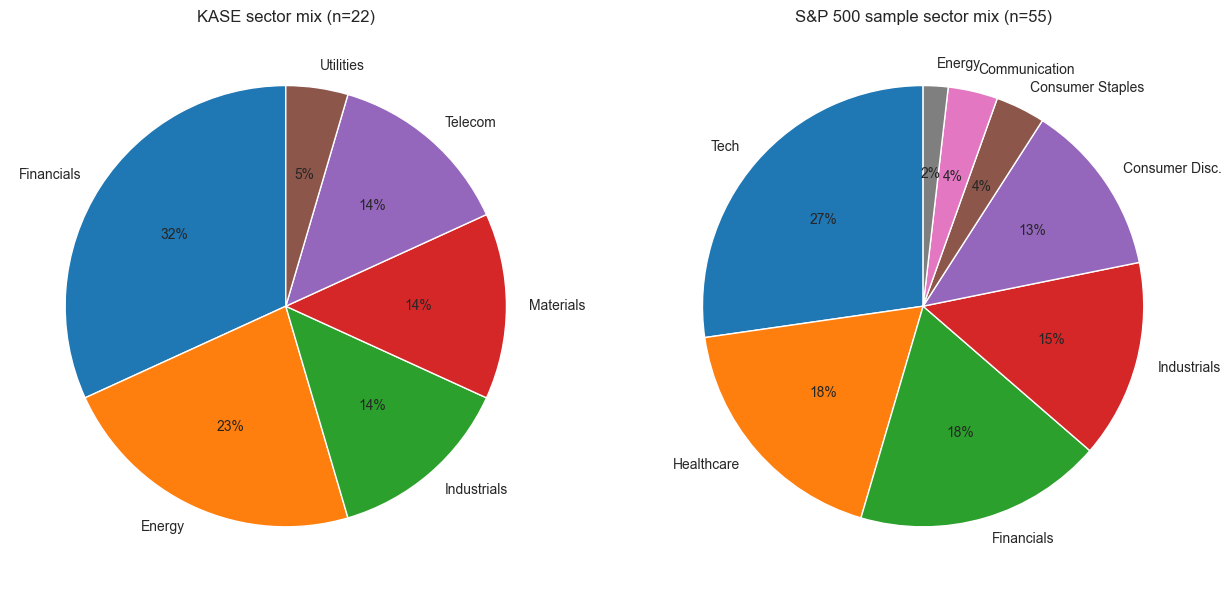

,KASE %,S&P %
sector,,
Tech,0.0,27.3
Financials,31.8,18.2
Healthcare,0.0,18.2
Industrials,13.6,14.5
Consumer Disc.,0.0,12.7
Consumer Staples,0.0,3.6
Communication,0.0,3.6
Energy,22.7,1.8
Materials,13.6,0.0


In [4]:
kase_mix = kase.drop_duplicates('ticker')['sector'].value_counts()
us_mix   = us.drop_duplicates('ticker')['sector'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
axes[0].pie(kase_mix, labels=kase_mix.index, autopct='%1.0f%%', startangle=90)
axes[0].set_title(f'KASE sector mix (n={kase_mix.sum()})')
axes[1].pie(us_mix, labels=us_mix.index, autopct='%1.0f%%', startangle=90)
axes[1].set_title(f'S&P 500 sample sector mix (n={us_mix.sum()})')
plt.tight_layout(); plt.show()

comp = pd.concat([
    (kase_mix / kase_mix.sum() * 100).rename('KASE %'),
    (us_mix   / us_mix.sum()   * 100).rename('S&P %'),
], axis=1).fillna(0).round(1).sort_values('S&P %', ascending=False)
comp

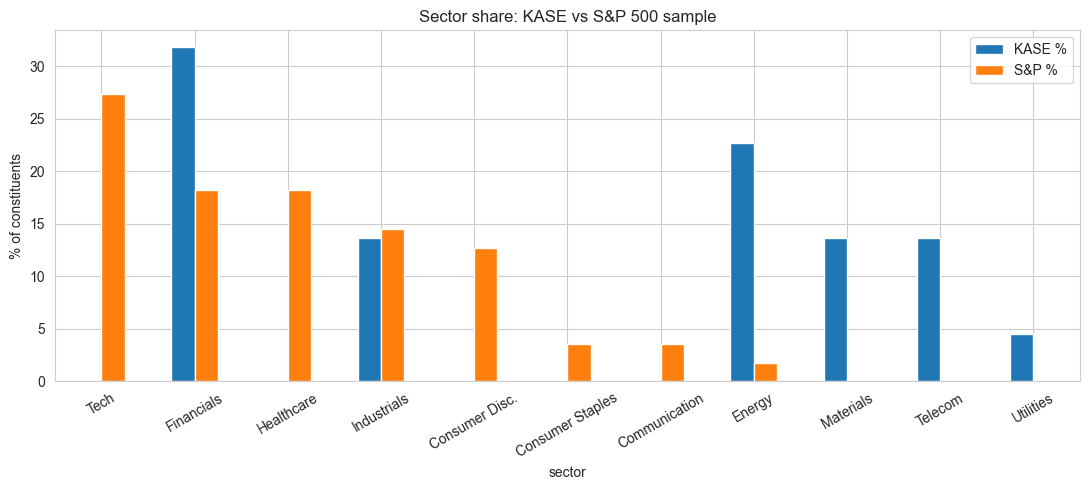

In [5]:
comp.plot(kind='bar', figsize=(11,5))
plt.title('Sector share: KASE vs S&P 500 sample'); plt.ylabel('% of constituents'); plt.xticks(rotation=30); plt.tight_layout(); plt.show()

## 4. Equal-weight index construction
We don't have an index time series, so we build an equal-weight daily index from each market's constituents using log returns.

/var/folders/bf/64hw841n7s742vsgsgy8rc2r0000gn/T/ipykernel_52414/3662452316.py:11: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  idx = pd.concat([kase_idx.rename('KASE EW'), us_idx.rename('S&P 500 sample EW')], axis=1).dropna()


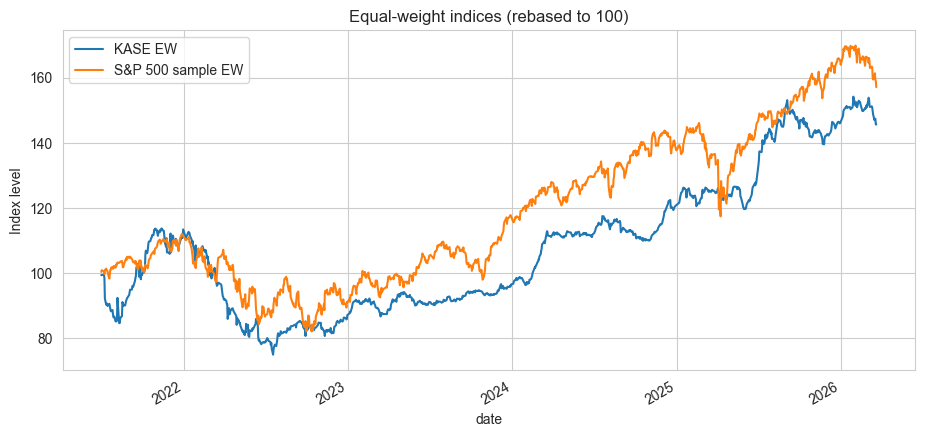

In [6]:
def equal_weight_index(df, price_col='adj_close'):
    px = df.pivot(index='date', columns='ticker', values=price_col).sort_index()
    ret = np.log(px / px.shift(1))
    idx_ret = ret.mean(axis=1)
    idx = np.exp(idx_ret.cumsum()) * 100
    return idx_ret.dropna(), idx.dropna()

kase_ret, kase_idx = equal_weight_index(kase)
us_ret,   us_idx   = equal_weight_index(us)

idx = pd.concat([kase_idx.rename('KASE EW'), us_idx.rename('S&P 500 sample EW')], axis=1).dropna()
idx.plot(title='Equal-weight indices (rebased to 100)'); plt.ylabel('Index level'); plt.show()

## 5. Risk / return summary

In [7]:
def summary(r, name):
    ann = 252
    mu  = r.mean() * ann
    sig = r.std() * np.sqrt(ann)
    sharpe = mu / sig
    eq = np.exp(r.cumsum())
    mdd = (eq / eq.cummax() - 1).min()
    total = eq.iloc[-1] - 1
    return pd.Series({'Total return': total, 'CAGR-ish (ann μ)': mu,
                      'Ann. volatility': sig, 'Sharpe (rf=0)': sharpe,
                      'Max drawdown': mdd, 'Best day': r.max(), 'Worst day': r.min()}, name=name)

stats = pd.concat([summary(kase_ret, 'KASE EW'), summary(us_ret, 'S&P 500 sample EW')], axis=1)
stats.round(4)

,KASE EW,S&P 500 sample EW
Total return,0.4566,0.5709
CAGR-ish (ann μ),0.0811,0.0960
Ann. volatility,0.1517,0.1752
Sharpe (rf=0),0.5346,0.5483
Max drawdown,-0.3412,-0.2678
Best day,0.0655,0.0884
Worst day,-0.0707,-0.0628


/var/folders/bf/64hw841n7s742vsgsgy8rc2r0000gn/T/ipykernel_52414/3948572626.py:3: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  pd.concat([dd_k.rename('KASE'), dd_u.rename('S&P')], axis=1).plot(


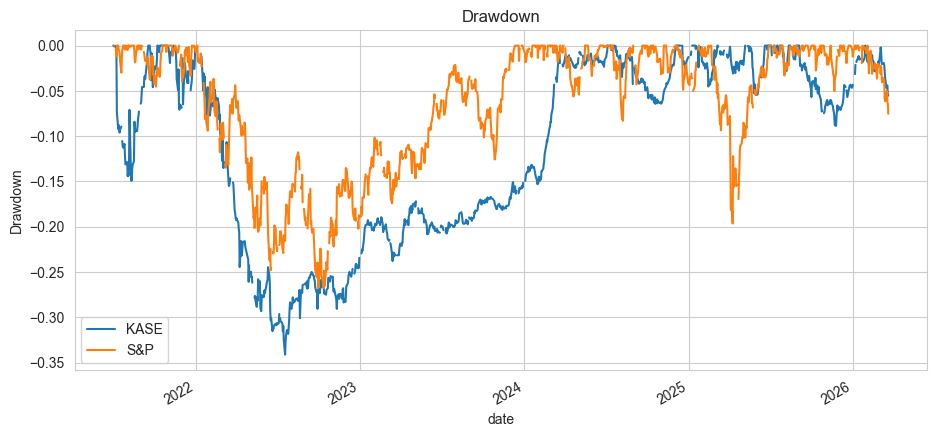

In [8]:
eq_k = np.exp(kase_ret.cumsum()); eq_u = np.exp(us_ret.cumsum())
dd_k = eq_k / eq_k.cummax() - 1;  dd_u = eq_u / eq_u.cummax() - 1
pd.concat([dd_k.rename('KASE'), dd_u.rename('S&P')], axis=1).plot(
    title='Drawdown'); plt.ylabel('Drawdown'); plt.show()

## 6. Return distributions

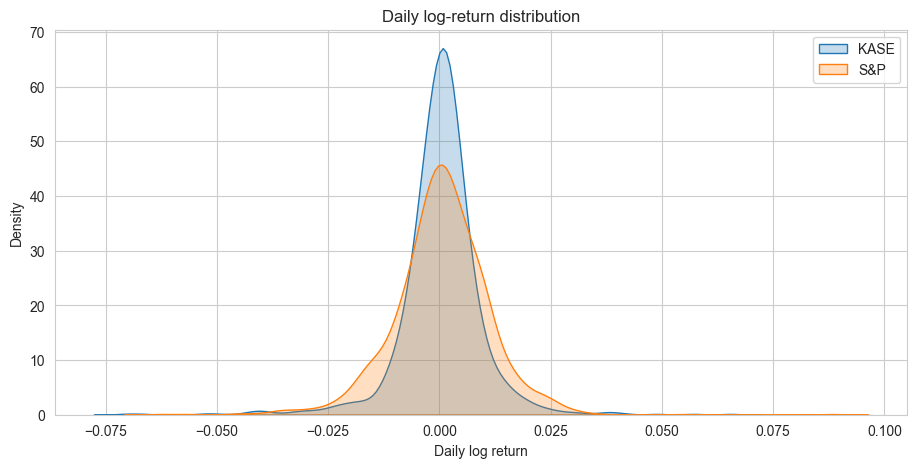

,KASE,S&P
Skew,-0.668,-0.039
Excess kurtosis,11.866,5.940


In [9]:
fig, ax = plt.subplots(figsize=(11,5))
sns.kdeplot(kase_ret, label='KASE', fill=True, ax=ax, clip=(-0.1, 0.1))
sns.kdeplot(us_ret,   label='S&P',  fill=True, ax=ax, clip=(-0.1, 0.1))
ax.set_title('Daily log-return distribution'); ax.set_xlabel('Daily log return'); ax.legend(); plt.show()

pd.DataFrame({
    'KASE': [kase_ret.skew(), kase_ret.kurt()],
    'S&P' : [us_ret.skew(),   us_ret.kurt()],
}, index=['Skew', 'Excess kurtosis']).round(3)

## 7. Correlation

/var/folders/bf/64hw841n7s742vsgsgy8rc2r0000gn/T/ipykernel_52414/1799828396.py:1: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  joined = pd.concat([kase_ret.rename('KASE'), us_ret.rename('S&P')], axis=1).dropna()


Static correlation: 0.011


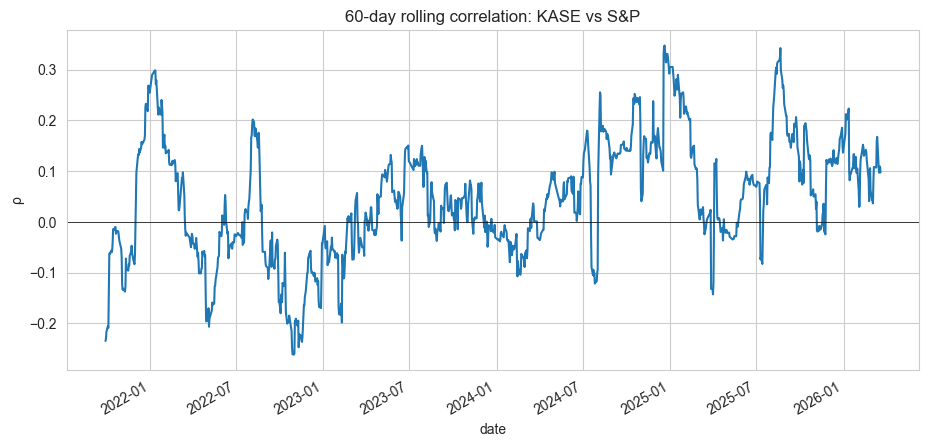

In [10]:
joined = pd.concat([kase_ret.rename('KASE'), us_ret.rename('S&P')], axis=1).dropna()
print('Static correlation:', joined.corr().iloc[0,1].round(3))

joined['KASE'].rolling(60).corr(joined['S&P']).plot(
    title='60-day rolling correlation: KASE vs S&P'); plt.ylabel('ρ'); plt.axhline(0, c='k', lw=0.5); plt.show()

## 8. Liquidity / volume

In [11]:
kase['dollar_vol'] = kase['close'] * kase['volume']
us['dollar_vol']   = us['close']   * us['volume']

liq = pd.DataFrame({
    'Median $-volume / ticker / day': [kase['dollar_vol'].median(), us['dollar_vol'].median()],
    'Mean $-volume / ticker / day':   [kase['dollar_vol'].mean(),   us['dollar_vol'].mean()],
    'Total $-volume':                 [kase['dollar_vol'].sum(),    us['dollar_vol'].sum()],
}, index=['KASE (KZT)', 'S&P (USD)']).T
liq.map(lambda x: f'{x:,.0f}')

,KASE (KZT),S&P (USD)
Median $-volume / ticker / day,"6,728,327,138","915,370,757"
Mean $-volume / ticker / day,"528,635,006,276","2,394,576,943"
Total $-volume,"11,487,238,686,368,862","201,637,746,082,682"


## 9. Top / bottom movers over the window

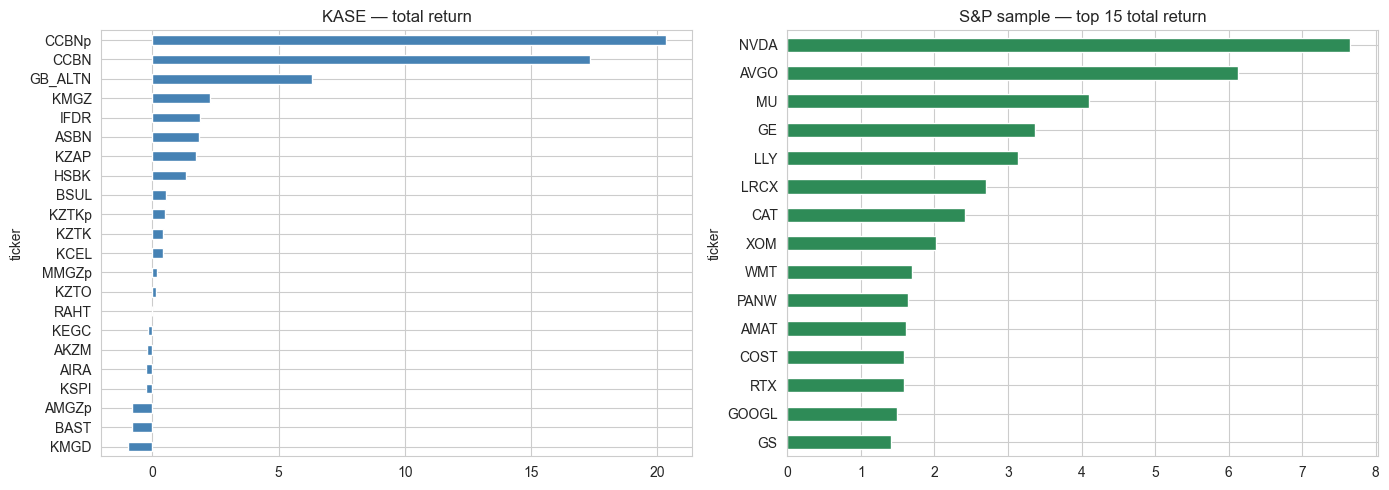

In [12]:
def total_return_by_ticker(df):
    out = (df.sort_values('date').groupby('ticker')['adj_close']
             .agg(lambda s: s.iloc[-1]/s.iloc[0] - 1))
    return out.sort_values(ascending=False)

kase_tr = total_return_by_ticker(kase)
us_tr   = total_return_by_ticker(us)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
kase_tr.plot(kind='barh', ax=axes[0], color='steelblue'); axes[0].set_title('KASE — total return')
us_tr.head(15).plot(kind='barh', ax=axes[1], color='seagreen'); axes[1].set_title('S&P sample — top 15 total return')
for a in axes: a.invert_yaxis()
plt.tight_layout(); plt.show()

## 10. Fundamentals snapshot (US only)
KASE file has no fundamentals; the US file includes P/E, P/B, margins, ROE, etc. Latest reading per ticker:

In [13]:
fund_cols = ['pe_ttm','pb','ps_ttm','gross_margin','operating_margin','net_margin',
             'roe','debt_to_equity','current_ratio','revenue_growth_yoy']
fund_cols = [c for c in fund_cols if c in us.columns]

latest = (us.sort_values('date').groupby('ticker').tail(1)[['ticker','sector'] + fund_cols]
            .set_index('ticker'))

sector_fund = latest.groupby('sector')[fund_cols].median().round(2)
sector_fund

,pe_ttm,pb,ps_ttm,gross_margin,operating_margin,net_margin,roe,debt_to_equity,current_ratio,revenue_growth_yoy
sector,,,,,,,,,,
Communication,25.49,1.63,5.21,0.41,0.20,0.15,0.02,0.43,0.93,0.05
Consumer Disc.,28.64,5.36,2.80,0.33,0.09,0.06,0.01,0.18,1.06,0.08
Consumer Staples,47.76,11.88,1.43,0.19,0.04,0.03,0.05,0.47,0.91,0.06
Energy,23.87,2.57,2.06,0.20,0.08,0.08,0.03,0.17,1.15,-0.01
Financials,15.84,2.21,4.01,0.58,0.34,0.26,0.04,1.29,8.29,0.10
Healthcare,24.02,3.42,4.23,0.67,0.22,0.16,0.04,0.74,1.40,0.06
Industrials,33.35,12.48,3.15,0.25,0.11,0.07,0.11,2.21,1.20,0.13
Tech,26.97,7.26,7.47,0.65,0.32,0.29,0.10,0.57,1.90,0.16


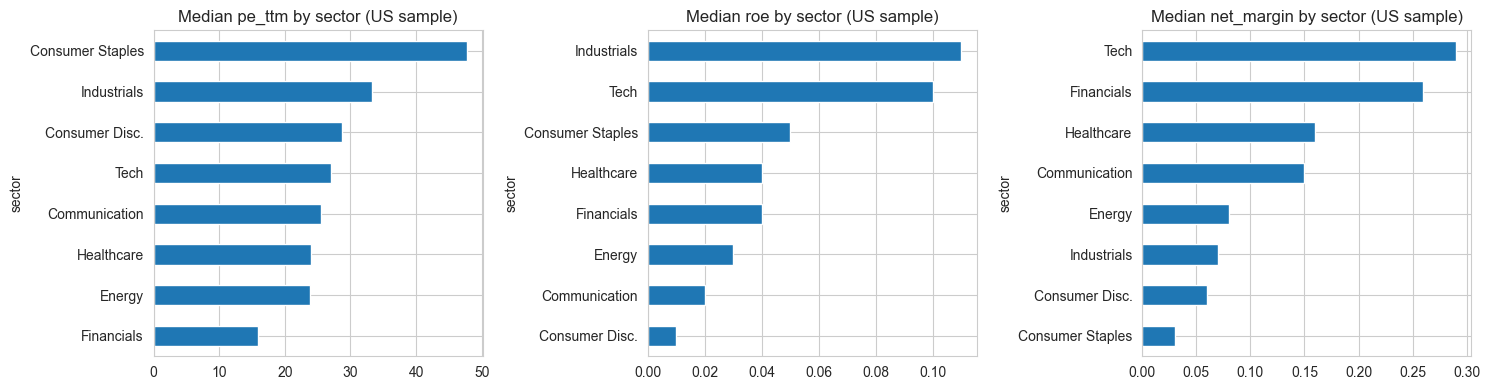

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['pe_ttm', 'roe', 'net_margin']):
    if col in sector_fund.columns:
        sector_fund[col].sort_values().plot(kind='barh', ax=ax)
        ax.set_title(f'Median {col} by sector (US sample)')
plt.tight_layout(); plt.show()